In [31]:
import pandas
import json

In [32]:
all_utts = pandas.read_csv("participant_utterances.csv")
all_utts.head(n=5)

,pid,utt,utt_type,conf,needs_review,utt_ind,outcome
0,p593,"I'd like to place a piece on a7, Is that a goo...",Common Ground Question,1.0,False,0,won
1,p593,is g2 a better choice?,Common Ground Question,1.0,False,1,won
2,p593,"I think b7 might be the best option, it takes ...",Think Aloud,1.0,False,2,won
3,p593,"I think b7 might be the best option, it takes ...",Common Ground Question,1.0,False,2,won
4,p593,how does c8 compare to b7?,Common Ground Question,1.0,False,3,won


In [33]:
import numpy as np
all_utt_types = list(all_utts["utt_type"].unique())
won_matrix = np.zeros((len(all_utt_types), len(all_utt_types)))
lost_matrix = np.zeros((len(all_utt_types), len(all_utt_types)))

In [34]:
# Iterate through participants
utt_seqs = {
    "won": [],
    "lost": []
}
for pid in all_utts["pid"].unique():
    rel_df = all_utts.loc[all_utts["pid"] == pid]
    outcome = rel_df["outcome"].unique()[0]
    full_utt_inds = rel_df["utt_ind"].unique()
    full_seq = []
    for uid in full_utt_inds:
        curr_utt = rel_df.loc[rel_df["utt_ind"] == uid]
        full_seq.append(list(curr_utt["utt_type"].unique()))
    utt_seqs[outcome].append(full_seq)


In [35]:
def process_seq(seq, mat):
    for i in range(0, len(seq) - 1):
        for u1 in seq[i]:
            for u2 in seq[i + 1]:
                ind_u1 = all_utt_types.index(u1)
                ind_u2 = all_utt_types.index(u2)
                mat[ind_u1][ind_u2] += 1

for s in utt_seqs["won"]:
    process_seq(s, won_matrix)

for s in utt_seqs["lost"]:
    process_seq(s, lost_matrix)

In [36]:
all_utt_types

['Common Ground Question',
 'Think Aloud',
 'Solution Request',
 'Knowledge Deficit Question',
 'Conversational Acknowledgment',
 'Metacomment',
 nan]

In [37]:
won_matrix

array([[36., 27., 16., 11., 18.,  8.,  0.],
       [29., 35., 15., 10., 17.,  9.,  0.],
       [11., 16., 14., 14.,  7.,  6.,  0.],
       [10., 11.,  7.,  9., 11.,  3.,  0.],
       [16., 15.,  6.,  7., 10.,  5.,  0.],
       [ 8., 11.,  3.,  3.,  6.,  5.,  0.],
       [ 0.,  0.,  1.,  0.,  0.,  1.,  0.]])

In [38]:
row_sums = won_matrix.sum(axis=1)
won_matrix = won_matrix / row_sums[:, np.newaxis]
won_matrix

array([[0.31034483, 0.23275862, 0.13793103, 0.09482759, 0.15517241,
        0.06896552, 0.        ],
       [0.25217391, 0.30434783, 0.13043478, 0.08695652, 0.14782609,
        0.07826087, 0.        ],
       [0.16176471, 0.23529412, 0.20588235, 0.20588235, 0.10294118,
        0.08823529, 0.        ],
       [0.19607843, 0.21568627, 0.1372549 , 0.17647059, 0.21568627,
        0.05882353, 0.        ],
       [0.27118644, 0.25423729, 0.10169492, 0.11864407, 0.16949153,
        0.08474576, 0.        ],
       [0.22222222, 0.30555556, 0.08333333, 0.08333333, 0.16666667,
        0.13888889, 0.        ],
       [0.        , 0.        , 0.5       , 0.        , 0.        ,
        0.5       , 0.        ]])

In [39]:
lost_matrix

array([[50., 25., 31., 21., 22., 10.,  0.],
       [32., 29., 28., 12., 20., 12.,  0.],
       [24., 29., 48., 18., 19., 11.,  0.],
       [17., 19., 13., 13., 13.,  4.,  0.],
       [13.,  9., 14.,  6., 13.,  6.,  0.],
       [ 7., 11.,  7., 11.,  6.,  3.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.]])

In [40]:
row_sums = lost_matrix.sum(axis=1)
lost_matrix = lost_matrix / row_sums[:, np.newaxis]
lost_matrix

/var/folders/st/lspvytf51f5c21v94mh8xj080000gn/T/ipykernel_88882/2302490330.py:2: RuntimeWarning: invalid value encountered in divide
  lost_matrix = lost_matrix / row_sums[:, np.newaxis]


array([[0.31446541, 0.1572327 , 0.19496855, 0.13207547, 0.13836478,
        0.06289308, 0.        ],
       [0.2406015 , 0.21804511, 0.21052632, 0.09022556, 0.15037594,
        0.09022556, 0.        ],
       [0.16107383, 0.19463087, 0.32214765, 0.12080537, 0.12751678,
        0.0738255 , 0.        ],
       [0.21518987, 0.24050633, 0.16455696, 0.16455696, 0.16455696,
        0.05063291, 0.        ],
       [0.21311475, 0.14754098, 0.2295082 , 0.09836066, 0.21311475,
        0.09836066, 0.        ],
       [0.15555556, 0.24444444, 0.15555556, 0.24444444, 0.13333333,
        0.06666667, 0.        ],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan]])

/var/folders/st/lspvytf51f5c21v94mh8xj080000gn/T/ipykernel_88882/385817805.py:32: RuntimeWarning: invalid value encountered in divide
  P = {g: C[g] / C[g].sum(axis=1, keepdims=True) for g in C}


KeyError: nan

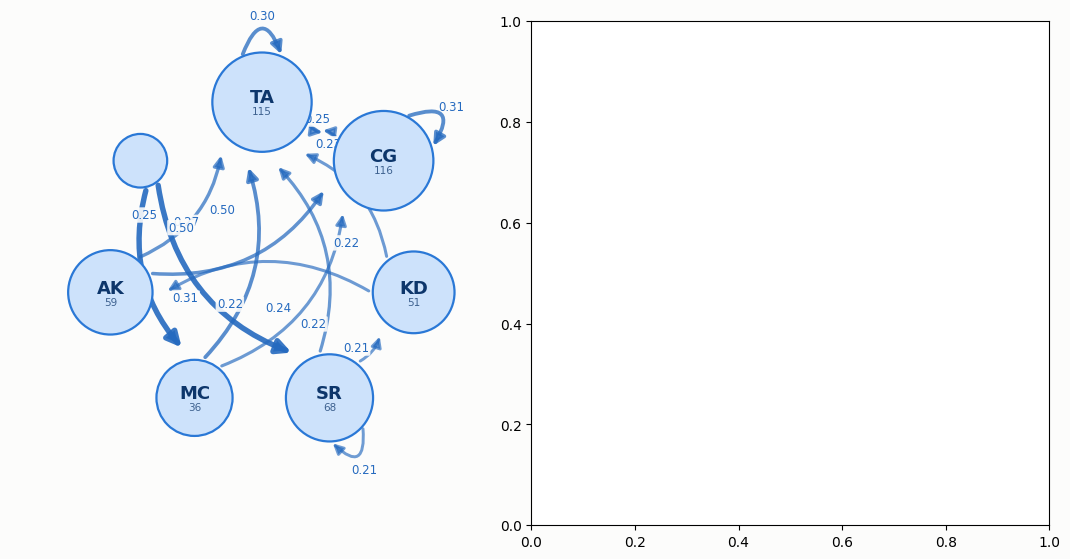

In [41]:
# --- Fig 1. State-transition diagram: what follows what, won vs lost ---------------
# The standard way to show a dialogue-act transition matrix: acts are nodes, arrows are
# P(next | current). Rebuilt from utt_seqs so the cell is idempotent.
import numpy as np, matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

ORDER = ["Think Aloud", "Common Ground Question", "Knowledge Deficit Question",
         "Solution Request", "Metacomment", "Conversational Acknowledgment"]
ORDER = [a for a in ORDER if a in all_utt_types] + [a for a in all_utt_types if a not in ORDER]
CODE = {"Think Aloud": "TA", "Common Ground Question": "CG", "Knowledge Deficit Question": "KD",
        "Solution Request": "SR", "Metacomment": "MC", "Conversational Acknowledgment": "AK"}
NAME = {"Think Aloud": "Think aloud", "Common Ground Question": "Common-ground Q",
        "Knowledge Deficit Question": "Knowledge-deficit Q", "Solution Request": "Solution request",
        "Metacomment": "Metacomment", "Conversational Acknowledgment": "Acknowledgment"}
idx = {a: i for i, a in enumerate(ORDER)}
K = len(ORDER)
SURFACE, INK, MUTED = "#fcfcfb", "#0b0b0b", "#898781"
ARROW, NODE_FILL, NODE_LINE, NODE_INK = "#256abf", "#cde2fb", "#2a78d6", "#0d366b"
MIN_P = 0.20                       # draw a transition only if it is at least this likely

def counts(seqs):
    """Raw t -> t+1 counts. A turn annotated with several acts contributes every pair."""
    m = np.zeros((K, K))
    for seq in seqs:
        for i in range(len(seq) - 1):
            for u1 in seq[i]:
                for u2 in seq[i + 1]:
                    m[idx[u1], idx[u2]] += 1
    return m

C = {g: counts(utt_seqs[g]) for g in ("won", "lost")}
P = {g: C[g] / C[g].sum(axis=1, keepdims=True) for g in C}

ang = np.pi / 2 - 2 * np.pi * np.arange(K) / K          # laid out clockwise from the top
pos = np.c_[np.cos(ang), np.sin(ang)]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 7), facecolor=SURFACE)
plt.subplots_adjust(wspace=0.02, top=0.88, bottom=0.16)
for ax, g in zip(axes, ("won", "lost")):
    ax.set_facecolor(SURFACE); ax.set_xlim(-1.62, 1.62); ax.set_ylim(-1.72, 1.52)
    ax.set_aspect("equal"); ax.axis("off")
    frm = C[g].sum(1)                                    # turns starting from each act
    rad = 0.15 + 0.17 * np.sqrt(frm / frm.max())

    for i in range(K):
        for j in range(K):
            p = P[g][i, j]
            if p < MIN_P:
                continue
            if i == j:                                   # self-loop, bulging outward
                out = pos[i] / np.hypot(*pos[i])
                rot = lambda v, t: np.array([v[0]*np.cos(t) - v[1]*np.sin(t),
                                             v[0]*np.sin(t) + v[1]*np.cos(t)])
                a = pos[i] + rot(out, 0.42) * rad[i]
                b = pos[i] + rot(out, -0.42) * rad[i]
                ax.add_patch(FancyArrowPatch(a, b, connectionstyle="arc3,rad=-1.35",
                                             arrowstyle="-|>", mutation_scale=11 + 20 * p,
                                             linewidth=0.9 + 6 * p, color=ARROW,
                                             alpha=0.45 + 0.45 * min(p / .45, 1), zorder=2))
                ax.text(*(pos[i] + out * (rad[i] + 0.235)), "%.2f" % p, ha="center", va="center",
                        fontsize=8.5, color=ARROW, zorder=3)
                continue
            d = pos[j] - pos[i]; L = np.hypot(*d)
            curve = 0.16 + 0.07 * L                      # long chords bow further from centre
            a = pos[i] + d / L * rad[i] * 1.04
            b = pos[j] - d / L * rad[j] * 1.30
            ax.add_patch(FancyArrowPatch(a, b, connectionstyle="arc3,rad=%.3f" % curve,
                                         arrowstyle="-|>", mutation_scale=11 + 20 * p,
                                         linewidth=0.9 + 6 * p, color=ARROW,
                                         alpha=0.45 + 0.45 * min(p / .45, 1), zorder=2))
            # label sits near the TAIL of its own arc, so a two-way pair is unambiguous
            n = np.array([-d[1], d[0]]) / L              # arc3 with rad>0 bulges to the left
            ctrl = (a + b) / 2 + n * curve * np.hypot(*(b - a))
            t = 0.28
            lp = (1 - t) ** 2 * a + 2 * t * (1 - t) * ctrl + t ** 2 * b
            ax.text(*(lp + n * 0.045), "%.2f" % p, ha="center", va="center",
                    fontsize=8.5, color=ARROW, zorder=3,
                    bbox=dict(boxstyle="round,pad=0.10", fc=SURFACE, ec="none", alpha=0.9))

    for i, act in enumerate(ORDER):
        ax.add_patch(plt.Circle(pos[i], rad[i], fc=NODE_FILL, ec=NODE_LINE, lw=1.6, zorder=4))
        ax.text(pos[i][0], pos[i][1] + 0.028, CODE[act], ha="center", va="center", fontsize=13,
                fontweight="bold", color=NODE_INK, zorder=5)
        ax.text(pos[i][0], pos[i][1] - 0.062, "%d" % frm[i], ha="center", va="center",
                fontsize=7.5, color=NODE_INK, alpha=0.75, zorder=5)
    ax.set_title("%s — %d participants, %d transitions"
                 % (g.capitalize(), len(utt_seqs[g]), int(C[g].sum())),
                 fontsize=12.5, color=INK, pad=2)

fig.suptitle("What follows what in the round-1 dialogue", fontsize=14.5, color=INK, y=0.965)
key = "   ".join("%s = %s" % (CODE[a], NAME[a]) for a in ORDER)
fig.text(0.5, 0.10, key, ha="center", fontsize=9.5, color=INK)
fig.text(0.5, 0.045, "Arrows are P(next act | current act), drawn only when ≥ %.2f; thickness "
         "scales with the probability. Looping arrow = the act repeats. Circle size and the "
         "small figure inside it = number of turns starting from that act." % MIN_P,
         ha="center", fontsize=9, color=MUTED)
plt.show()

In [42]:
# --- Fig 2. Sequence grid: every round-1 conversation, turn by turn -----------------
# The sequence-analysis staple (cf. TraMineR seqIplot): one row per participant, one
# column per turn. Act identity is carried by the two-letter code rather than by colour --
# six categorical hues cannot be made distinguishable under colour-vision deficiency,
# so colour here only splits asking-the-AI from everything else.
import numpy as np, matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

ASKING = {"Common Ground Question", "Knowledge Deficit Question", "Solution Request"}
SURFACE, INK, MUTED = "#fcfcfb", "#0b0b0b", "#898781"
ASK_FILL, ASK_INK, OTH_FILL, OTH_INK = "#cde2fb", "#0d366b", "#eeeeea", "#52514e"

rows = []                                    # (outcome, pid, [[acts at turn 1], ...])
for pid in all_utts["pid"].unique():
    rel = all_utts.loc[all_utts["pid"] == pid]
    rows.append((rel["outcome"].unique()[0], pid,
                 [list(rel.loc[rel["utt_ind"] == u, "utt_type"].unique())
                  for u in rel["utt_ind"].unique()]))
rows.sort(key=lambda r: (r[0] != "won", -len(r[2])))          # won block first, longest first
T = max(len(r[2]) for r in rows)

fig, ax = plt.subplots(figsize=(1.05 * T + 3.2, 0.42 * len(rows) + 2.6), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for y, (outcome, pid, seq) in enumerate(rows):
    for t, acts in enumerate(seq):
        ask = any(a in ASKING for a in acts)
        ax.add_patch(Rectangle((t + 0.06, y + 0.10), 0.88, 0.80, lw=0,
                               fc=ASK_FILL if ask else OTH_FILL))
        ax.text(t + 0.5, y + 0.5, "+".join(CODE[a] for a in acts), ha="center", va="center",
                fontsize=8.5 if len(acts) < 2 else 7.0, fontweight="semibold",
                color=ASK_INK if ask else OTH_INK)

n_won = sum(1 for r in rows if r[0] == "won")
ax.axhline(n_won, color=INK, lw=1.1, alpha=0.55)              # won / lost divider
for lab, y0, y1 in (("WON  (%d)" % n_won, 0, n_won),
                    ("LOST  (%d)" % (len(rows) - n_won), n_won, len(rows))):
    ax.text(-0.35, (y0 + y1) / 2, lab, ha="right", va="center", fontsize=10.5, color=INK,
            fontweight="semibold", rotation=90)
ax.set_xlim(-0.42, T + 0.05); ax.set_ylim(len(rows), 0)       # first participant at the top
ax.set_xticks(np.arange(T) + 0.5); ax.set_xticklabels(np.arange(1, T + 1), fontsize=9, color=INK)
ax.set_yticks([]); ax.tick_params(length=0)
ax.set_xlabel("turn in the conversation", fontsize=10.5, color=MUTED, labelpad=6)
for s in ax.spines.values():
    s.set_visible(False)
ax.xaxis.set_ticks_position("top"); ax.xaxis.set_label_position("top")

ax.set_title("Every round-1 conversation, one row per participant", fontsize=13.5, color=INK,
             loc="left", pad=28)
key = "   ".join("%s = %s" % (CODE[a], NAME[a]) for a in ORDER)
fig.text(0.5, 0.048, key, ha="center", fontsize=9.5, color=INK)
fig.text(0.5, 0.028, "Shaded = the participant asked the AI for something (CG / KD / SR); "
         "unshaded = their own reasoning or interaction management.", ha="center",
         fontsize=9, color=MUTED)
fig.text(0.5, 0.012, "“A+B” = one turn annotated with more than one act. Rows sorted "
         "longest-first within each group.", ha="center", fontsize=9, color=MUTED)
plt.subplots_adjust(top=0.92, bottom=0.075, left=0.06, right=0.99)
plt.show()

KeyError: nan

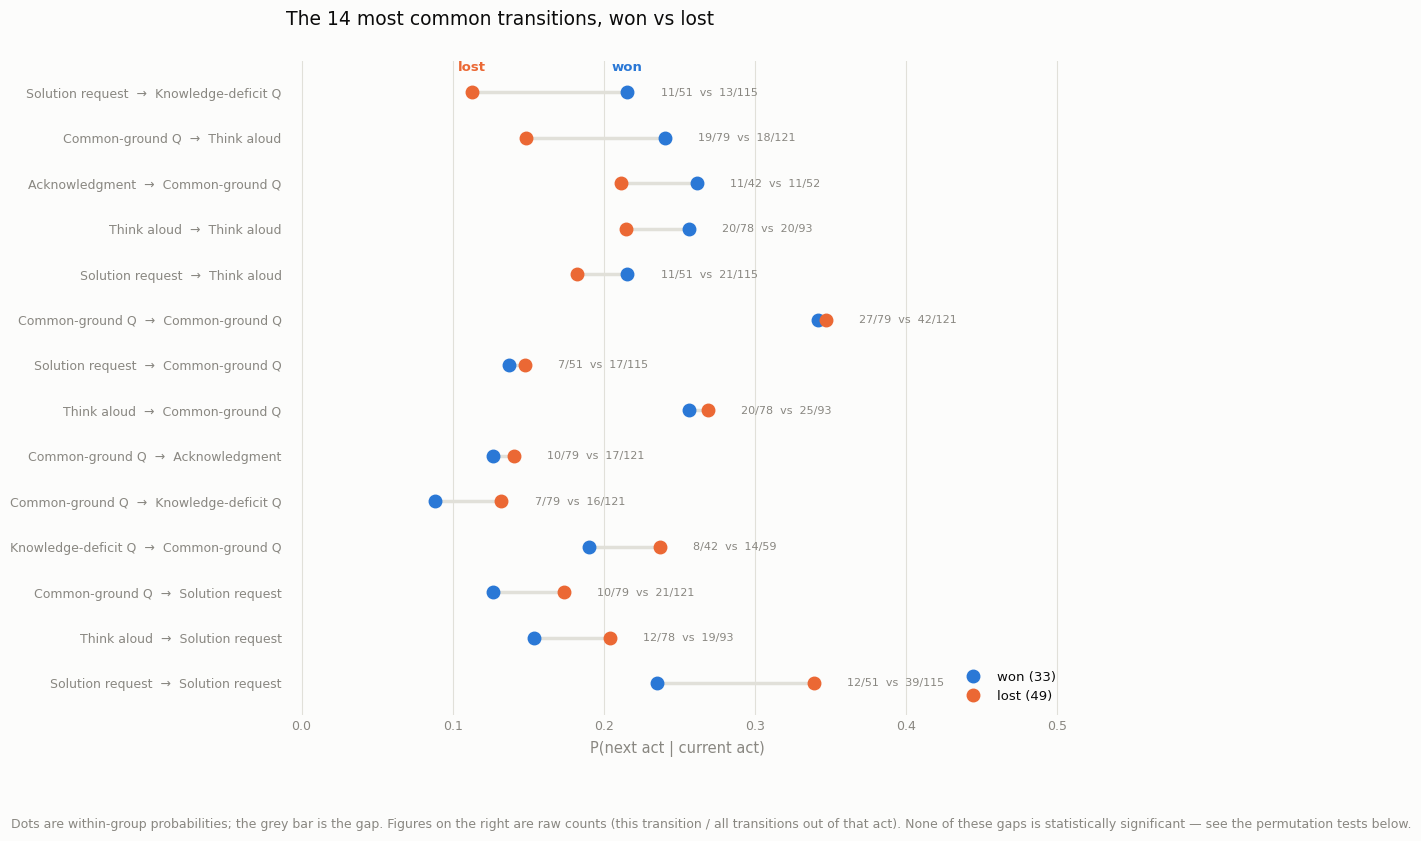

In [ ]:
# --- Fig 3. Won vs lost on the transitions that actually occur often ----------------
# Replaces the difference matrix: one row per transition, two dots, so the comparison is
# a single left-right read instead of 36 signed numbers. Ordered by the size of the gap.
import numpy as np, matplotlib.pyplot as plt

TOP_N = 14                                    # most frequent transitions, pooled across groups
SURFACE, INK, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#898781", "#e1e0d9"
WON_C, LOST_C = "#2a78d6", "#eb6834"          # categorical slots 1 and 2

Cw, Cl = C["won"], C["lost"]
Pw, Pl = P["won"], P["lost"]
pooled = Cw + Cl
cells = [tuple(x) for x in np.dstack(np.unravel_index(np.argsort(-pooled.ravel()),
                                                      (K, K)))[0][:TOP_N]]
cells.sort(key=lambda rc: Pw[rc] - Pl[rc])    # biggest lost-lean at the bottom

fig, ax = plt.subplots(figsize=(11, 0.46 * len(cells) + 2.4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for y, (r, c) in enumerate(cells):
    ax.plot([Pw[r, c], Pl[r, c]], [y, y], color=GRID, lw=2.5, zorder=1, solid_capstyle="round")
    ax.plot(Pw[r, c], y, "o", ms=9, color=WON_C, zorder=3)
    ax.plot(Pl[r, c], y, "o", ms=9, color=LOST_C, zorder=3)
    ax.text(max(Pw[r, c], Pl[r, c]) + 0.022, y, "%d/%d  vs  %d/%d"
            % (Cw[r, c], Cw[r].sum(), Cl[r, c], Cl[r].sum()), va="center", fontsize=8,
            color=MUTED)
ax.set_yticks(range(len(cells)))
ax.set_yticklabels(["%s  →  %s" % (NAME[ORDER[r]], NAME[ORDER[c]]) for r, c in cells],
                   fontsize=9.5, color=INK)
ax.set_ylim(-0.7, len(cells) - 0.3)
ax.set_xlim(-0.01, max(Pw[tuple(zip(*cells))].max(), Pl[tuple(zip(*cells))].max()) + 0.16)
ax.set_xlabel("P(next act | current act)", fontsize=10.5, color=MUTED, labelpad=6)
ax.xaxis.set_major_formatter(lambda v, _: "%.1f" % v)
ax.grid(axis="x", color=GRID, lw=0.8)
ax.set_axisbelow(True)
ax.tick_params(length=0, colors=MUTED, labelsize=9)
for s in ax.spines.values():
    s.set_visible(False)
top = len(cells) - 1                          # direct labels on the top row, plus a legend
for val, col, lab in ((Pw[cells[top]], WON_C, "won"), (Pl[cells[top]], LOST_C, "lost")):
    ax.text(val, top + 0.42, lab, ha="center", va="bottom", fontsize=9.5, color=col,
            fontweight="semibold")
ax.legend(handles=[plt.Line2D([], [], marker="o", ls="", ms=9, color=WON_C,
                              label="won (%d)" % len(utt_seqs["won"])),
                   plt.Line2D([], [], marker="o", ls="", ms=9, color=LOST_C,
                              label="lost (%d)" % len(utt_seqs["lost"]))],
          loc="lower right", frameon=False, fontsize=9.5, labelcolor=INK)

ax.set_title("The %d most common transitions, won vs lost" % len(cells), fontsize=13.5,
             color=INK, loc="left", pad=26)
fig.text(0.02, 0.012, "Dots are within-group probabilities; the grey bar is the gap. Figures on "
         "the right are raw counts (this transition / all transitions out of that act). "
         "None of these gaps is statistically significant — see the permutation tests below.",
         fontsize=9, color=MUTED)
plt.subplots_adjust(top=0.88, bottom=0.14, left=0.27, right=0.98)
plt.show()

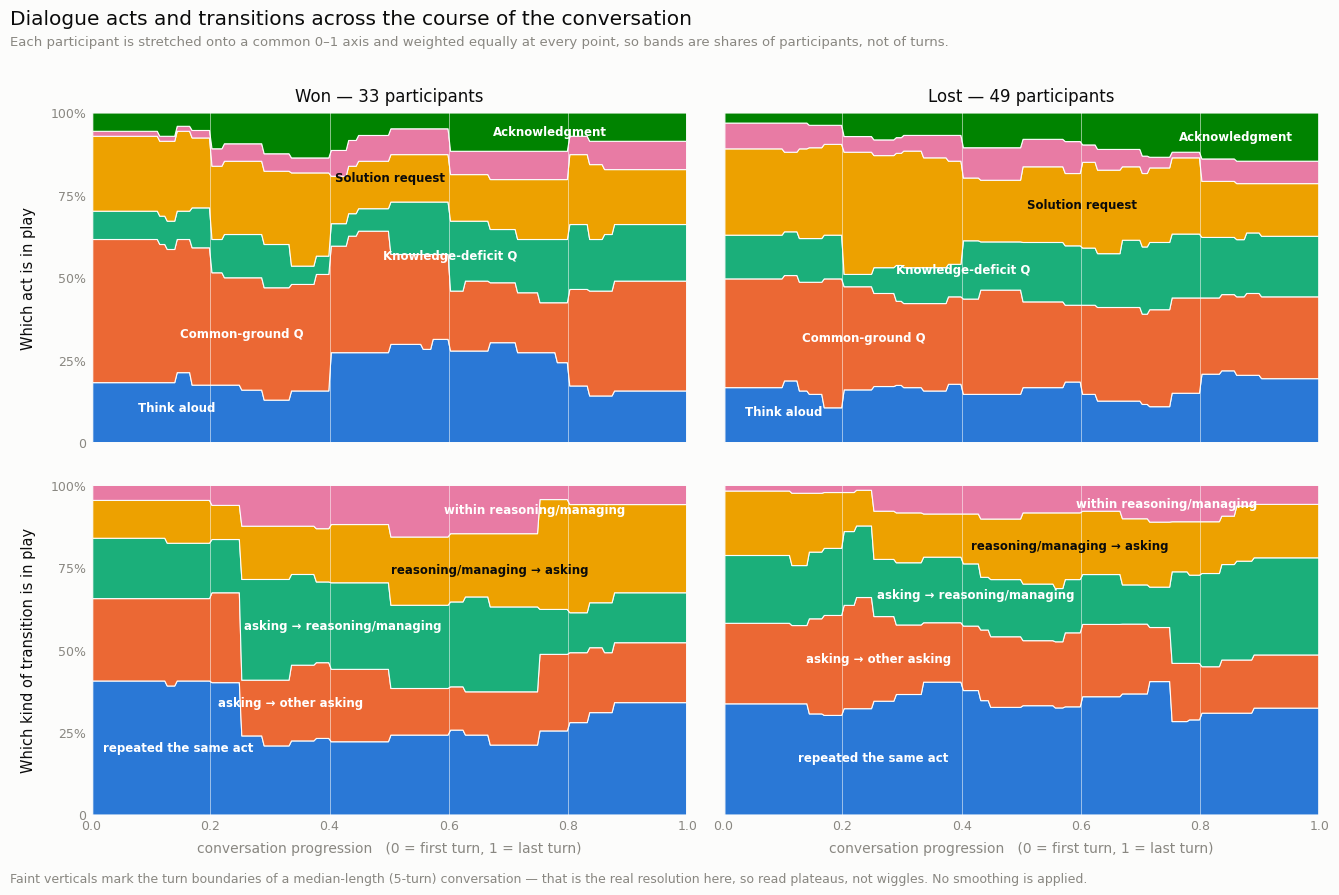

In [ ]:
# --- Fig 4. Stacked areas over normalised conversation progression -----------------
# Rows: which act is in play (top) / which kind of transition is in play (bottom).
# Cols: won / lost.   x = position within the conversation, 0 = start, 1 = end.
#
# Normalisation: turn i of n OCCUPIES the interval [i/n, (i+1)/n), so every conversation
# tiles [0, 1] whatever its length; transitions do the same over the n-1 transition slots.
# Point normalisation (x = i/(n-1)) is the tempting alternative -- don't: it is undefined
# for n = 1 and gives the first and last turn half the area of every middle turn.
# Each participant contributes exactly mass 1.0 at every grid point, and a turn labelled
# with several acts splits its mass across them, so the bands sum to 1 everywhere (asserted
# below). Averaging is over PARTICIPANTS, so the one 30-turn conversation cannot dominate.
# Depends on ORDER / NAME / idx from Fig 1.
import numpy as np, matplotlib.pyplot as plt

G = 240                                   # grid points across [0, 1]
GRID = (np.arange(G) + 0.5) / G
ASKING = {"Common Ground Question", "Knowledge Deficit Question", "Solution Request"}
TR_BANDS = ["repeated the same act", "asking → other asking", "asking → reasoning/managing",
            "reasoning/managing → asking", "within reasoning/managing"]

SURFACE, INK, MUTED = "#fcfcfb", "#0b0b0b", "#898781"
BAND = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]   # fixed slot order

def _lum(hx):                             # WCAG relative luminance, to pick the label ink
    c = [int(hx[i:i+2], 16) / 255 for i in (1, 3, 5)]
    c = [x / 12.92 if x <= 0.04045 else ((x + 0.055) / 1.055) ** 2.4 for x in c]
    return 0.2126 * c[0] + 0.7152 * c[1] + 0.0722 * c[2]

def act_area(seqs):
    """(G, K) act proportions over normalised progression, averaged over participants."""
    out = np.zeros((G, len(ORDER)))
    for seq in seqs:
        n = len(seq)
        cover = np.minimum((GRID * n).astype(int), n - 1)       # turn covering each grid point
        for k, ti in enumerate(cover):
            acts = seq[ti]
            for a in acts:
                out[k, idx[a]] += 1.0 / len(acts)              # mass 1.0 per participant
    out /= len(seqs)
    assert np.allclose(out.sum(1), 1), "act bands must sum to 1 at every x"
    return out

def transition_area(seqs):
    """(G, 5) transition-type proportions; participants with a single turn are excluded."""
    usable = [s for s in seqs if len(s) >= 2]
    out = np.zeros((G, len(TR_BANDS)))
    for seq in usable:
        m = len(seq) - 1                                       # transitions, not turns
        cover = np.minimum((GRID * m).astype(int), m - 1)
        for k, ti in enumerate(cover):
            a1, a2 = seq[ti], seq[ti + 1]
            w = 1.0 / (len(a1) * len(a2))                      # split across the act pairs
            for u1 in a1:
                for u2 in a2:
                    if u1 == u2:
                        b = 0
                    elif u1 in ASKING and u2 in ASKING:
                        b = 1
                    elif u1 in ASKING:
                        b = 2
                    elif u2 in ASKING:
                        b = 3
                    else:
                        b = 4
                    out[k, b] += w
    out /= len(usable)
    assert np.allclose(out.sum(1), 1), "transition bands must sum to 1 at every x"
    return out, len(seqs) - len(usable)

seqs = {g: utt_seqs[g] for g in ("won", "lost")}
ACT = {g: act_area(seqs[g]) for g in seqs}
TR = {g: transition_area(seqs[g]) for g in seqs}
dropped = sum(TR[g][1] for g in TR)

fig, axes = plt.subplots(2, 2, figsize=(13.5, 9), facecolor=SURFACE, sharex=True, sharey=True)
for row, (labels, data, title) in enumerate((
        ([NAME[a] for a in ORDER], {g: ACT[g] for g in ACT}, "Which act is in play"),
        (TR_BANDS, {g: TR[g][0] for g in TR}, "Which kind of transition is in play"))):
    for col, g in enumerate(("won", "lost")):
        ax = axes[row, col]
        ax.set_facecolor(SURFACE)
        Y = data[g]
        cum = np.vstack([np.zeros(G), Y.cumsum(axis=1).T])      # band edges, bottom to top
        B = Y.shape[1]
        for b in range(B):
            ax.fill_between(GRID, cum[b], cum[b + 1], facecolor=BAND[b], lw=0.8,
                            edgecolor=SURFACE, zorder=2)        # surface gap between fills
            # Direct label in the band's thickest place -- three of these fills are sub-3:1
            # against the surface, so labels are required, not optional. Each band searches
            # its own x-window so labels spread out instead of stacking on one another.
            thick = Y[:, b]
            c = 0.10 + 0.80 * (b + 0.5) / B                     # this band's window centre
            w = 0.40 / B
            win = (GRID >= c - w) & (GRID <= c + w)
            k = int(np.flatnonzero(win)[thick[win].argmax()]) if thick[win].max() >= 0.09 \
                else (int(thick.argmax()) if thick.max() >= 0.12 else None)
            if k is None:
                continue
            half = 0.006 * len(labels[b])                       # keep long labels off the edges
            ax.text(min(max(GRID[k], half + 0.02), 0.98 - half),
                    (cum[b, k] + cum[b + 1, k]) / 2, labels[b],
                    ha="center", va="center", fontsize=8.5, fontweight="semibold", zorder=4,
                    color="#ffffff" if _lum(BAND[b]) < 0.35 else "#0b0b0b")
        for v in np.arange(0.2, 1.0, 0.2):                      # median-length turn boundaries
            ax.axvline(v, color=SURFACE, lw=0.7, alpha=0.55, zorder=3)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_yticks([0, .25, .5, .75, 1])
        ax.set_yticklabels(["0", "25%", "50%", "75%", "100%"], fontsize=9, color=MUTED)
        ax.tick_params(length=0, colors=MUTED, labelsize=9)
        for s in ax.spines.values():
            s.set_visible(False)
        if row == 0:
            ax.set_title("%s — %d participants" % (g.capitalize(), len(seqs[g])),
                         fontsize=12, color=INK, pad=8)
        if row == 1:
            ax.set_xlabel("conversation progression   (0 = first turn, 1 = last turn)",
                          fontsize=10, color=MUTED, labelpad=6)
        if col == 0:
            ax.set_ylabel(title, fontsize=10.5, color=INK, labelpad=10)

fig.suptitle("Dialogue acts and transitions across the course of the conversation",
             fontsize=14.5, color=INK, x=0.015, ha="left", y=0.985)
fig.text(0.015, 0.945, "Each participant is stretched onto a common 0–1 axis and weighted "
         "equally at every point, so bands are shares of participants, not of turns.",
         fontsize=9.5, color=MUTED, ha="left")
fig.text(0.015, 0.015, "Faint verticals mark the turn boundaries of a median-length (5-turn) "
         "conversation — that is the real resolution here, so read plateaus, not wiggles. "
         "No smoothing is applied." + (" %d single-turn participant(s) excluded from the "
         "transition row." % dropped if dropped else ""), fontsize=9, color=MUTED, ha="left")
plt.subplots_adjust(top=0.87, bottom=0.09, left=0.075, right=0.985, hspace=0.13, wspace=0.06)
plt.show()

In [ ]:
# --- Significance of the transitions -----------------------------------------------
# Two separate questions, two separate nulls:
#   Q1  Is there first-order structure at all, i.e. does the act at t predict the act
#       at t+1 beyond each participant's own base rates?
#       Null: shuffle the ORDER of each participant's turns, keep their act composition.
#   Q2  Do the won and lost matrices differ?
#       Null: permute the won/lost label across PARTICIPANTS.
# The clustering matters: 326 transitions come from 32 people, so a plain chi-square or
# per-cell Fisher on the pooled table treats n as ~10x larger than it is. Both tests
# below resample whole participants, which is what keeps the p-values honest.
# Tested at three granularities (omnibus -> per from-act row -> per cell) with
# Benjamini-Hochberg FDR at each level, so a single cell is never read off cold.
# Depends on ORDER / idx / K from the heatmap cell above.
import numpy as np

B_LABEL, B_SHUFFLE, B_BOOT = 10_000, 2_000, 5_000     # raise B_SHUFFLE if you want tighter p's
rng = np.random.default_rng(0)

# per-participant sequences + labels (kept aligned, unlike utt_seqs which pools by group)
p_seqs, p_labels = [], []
for pid in all_utts["pid"].unique():
    rel = all_utts.loc[all_utts["pid"] == pid]
    p_seqs.append([list(rel.loc[rel["utt_ind"] == u, "utt_type"].unique())
                   for u in rel["utt_ind"].unique()])
    p_labels.append(rel["outcome"].unique()[0])
p_labels = np.array(p_labels)
is_won = p_labels == "won"

def cmat(seq):
    m = np.zeros((K, K))
    for i in range(len(seq) - 1):
        for u1 in seq[i]:
            for u2 in seq[i + 1]:
                m[idx[u1], idx[u2]] += 1
    return m

Cp = np.stack([cmat(s) for s in p_seqs])              # (participants, K, K)

def row_norm(M):
    rs = M.sum(1, keepdims=True)
    return np.divide(M, rs, out=np.full_like(M, np.nan), where=rs > 0)

def bh(p):
    """Benjamini-Hochberg q-values, same shape as p."""
    p = np.asarray(p, float); n = p.size; o = np.argsort(p.ravel()); q = np.empty(n)
    q[o] = np.minimum.accumulate((p.ravel()[o] * n / np.arange(1, n + 1))[::-1])[::-1]
    return np.clip(q, 0, 1).reshape(p.shape)

# ---- Q2: won vs lost, by participant-label permutation --------------------------------
def diff_stat(won_mask):
    Cw, Cl = Cp[won_mask].sum(0), Cp[~won_mask].sum(0)
    Dm = row_norm(Cl) - row_norm(Cw)
    w = Cw.sum(1) + Cl.sum(1); w = w / w.sum()        # weight rows by how much data they carry
    return Dm, np.nansum(w[:, None] * np.abs(Dm)), Cw, Cl

D_obs, T_obs, Cw, Cl = diff_stat(is_won)
D_null = np.empty((B_LABEL, K, K)); T_null = np.empty(B_LABEL)
for b in range(B_LABEL):
    m = np.zeros(len(p_seqs), bool)
    m[rng.choice(len(p_seqs), is_won.sum(), replace=False)] = True
    D_null[b], T_null[b], _, _ = diff_stat(m)

perm_p = lambda null, obs: (1 + (null >= obs).sum(0)) / (1 + len(null))
print("Q2  won (n=%d) vs lost (n=%d) participants, %d transitions, B=%d"
      % (is_won.sum(), (~is_won).sum(), Cp.sum(), B_LABEL))
print("    OMNIBUS  row-weighted TV distance = %.3f   p = %.4f" % (T_obs, perm_p(T_null, T_obs)))

tv_row = np.nansum(np.abs(D_obs), axis=1) / 2
p_row = perm_p(np.nansum(np.abs(D_null), axis=2) / 2, tv_row)
q_row = bh(p_row)
print("    PER-ROW (next-act distribution given the from-act):")
for r in np.argsort(p_row):
    print("      %-30s TV=%.3f  p=%.4f  q=%.3f   n_won=%3d n_lost=%3d"
          % (ORDER[r], tv_row[r], p_row[r], q_row[r], Cw[r].sum(), Cl[r].sum()))

p_cell = perm_p(np.abs(D_null), np.abs(D_obs)); q_cell = bh(p_cell)
print("    PER-CELL  raw p<.05: %d/36   BH q<.05: %d   q<.10: %d"
      % ((p_cell < .05).sum(), (q_cell < .05).sum(), (q_cell < .10).sum()))
for r, c in np.dstack(np.unravel_index(np.argsort(p_cell.ravel()), (K, K)))[0][:5]:
    print("      %-24s -> %-24s D=%+.2f  p=%.4f  q=%.3f  (won %d/%d, lost %d/%d)"
          % (ORDER[r], ORDER[c], D_obs[r, c], p_cell[r, c], q_cell[r, c],
             Cw[r, c], Cw[r].sum(), Cl[r, c], Cl[r].sum()))

# ---- Q1: first-order structure, by within-participant turn shuffle -------------------
def chi2_indep(M):
    e = M.sum(1, keepdims=True) * M.sum(0, keepdims=True) / M.sum()
    return np.nansum((M - e) ** 2 / np.where(e > 0, e, np.nan))

print("\nQ1  first-order dependence vs within-participant turn shuffle, B=%d" % B_SHUFFLE)
for name, mask in (("all", np.ones(len(p_seqs), bool)), ("won", is_won), ("lost", ~is_won)):
    C_obs = Cp[mask].sum(0); x_obs = chi2_indep(C_obs)
    sub = [p_seqs[i] for i in np.flatnonzero(mask)]
    xs = np.empty(B_SHUFFLE); cells = np.empty((B_SHUFFLE, K, K))
    for b in range(B_SHUFFLE):
        tot = np.zeros((K, K))
        for s in sub:
            perm = list(s); rng.shuffle(perm); tot += cmat(perm)
        cells[b] = tot; xs[b] = chi2_indep(tot)
    # two-sided per-cell p: is the observed count high or low against its own null?
    pc = (1 + 2 * np.minimum((cells >= C_obs).sum(0), (cells <= C_obs).sum(0))) / (1 + B_SHUFFLE)
    qc = bh(pc)
    print("    %-4s chi2-from-independence = %6.2f  p = %.4f   cells with q<.05: %d"
          % (name, x_obs, perm_p(xs, x_obs), (qc < .05).sum()))
    if name == "all":
        for r, c in np.dstack(np.unravel_index(np.argsort(pc.ravel()), (K, K)))[0][:3]:
            print("        %-24s -> %-24s obs=%3d vs null mean %4.1f  p=%.4f q=%.3f"
                  % (ORDER[r], ORDER[c], C_obs[r, c], cells[:, r, c].mean(), pc[r, c], qc[r, c]))

# ---- effect size: cluster bootstrap CI on the difference ------------------------------
# Resamples participants (not transitions) with replacement inside each group. With only
# 10 winners this percentile CI is over-optimistic -- report it as an effect size, and let
# the permutation q above decide significance. They disagree here, and the permutation wins.
iw, il = np.flatnonzero(is_won), np.flatnonzero(~is_won)
boot = np.empty((B_BOOT, K, K))
for b in range(B_BOOT):
    boot[b] = (row_norm(Cp[rng.choice(il, il.size, True)].sum(0))
               - row_norm(Cp[rng.choice(iw, iw.size, True)].sum(0)))
lo, hi = np.nanpercentile(boot, [2.5, 97.5], axis=0)
print("\nCluster-bootstrap 95%% CI on D (lost - won), cells ranked by |D|:")
for r, c in np.dstack(np.unravel_index(np.argsort(-np.abs(D_obs).ravel()), (K, K)))[0][:5]:
    print("    %-24s -> %-24s D=%+.2f  [%+.2f, %+.2f]"
          % (ORDER[r], ORDER[c], D_obs[r, c], lo[r, c], hi[r, c]))

Q2  won (n=33) vs lost (n=49) participants, 793 transitions, B=10000
    OMNIBUS  row-weighted TV distance = 0.257   p = 0.7338
    PER-ROW (next-act distribution given the from-act):
      Solution Request               TV=0.155  p=0.2947  q=0.690   n_won= 51 n_lost=115
      Metacomment                    TV=0.236  p=0.3362  q=0.690   n_won= 26 n_lost= 35
      Conversational Acknowledgment  TV=0.181  p=0.3449  q=0.690   n_won= 42 n_lost= 52
      Common Ground Question         TV=0.110  p=0.5684  q=0.853   n_won= 79 n_lost=121
      Think Aloud                    TV=0.087  p=0.8209  q=0.965   n_won= 78 n_lost= 93
      Knowledge Deficit Question     TV=0.077  p=0.9653  q=0.965   n_won= 42 n_lost= 59
    PER-CELL  raw p<.05: 0/36   BH q<.05: 0   q<.10: 0
      Conversational Acknowledgment -> Solution Request         D=+0.14  p=0.0574  q=0.929  (won 3/42, lost 11/52)
      Common Ground Question   -> Think Aloud              D=-0.09  p=0.0724  q=0.929  (won 19/79, lost 18/121)
      